<a href="https://colab.research.google.com/github/thanvika05/Thanvika_CodeBooster_2026/blob/main/Day10/Day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import sqlite3

In [3]:
df=pd.read_csv("student_performance.csv")
df.head()
print("The Dataset is Completely added!!")

The Dataset is Completely added!!


In [4]:
conn = sqlite3.connect('student.db')
df.to_sql('students', conn, if_exists='replace', index=False)
print("Data imported successfully!")

Data imported successfully!


In [5]:
query = "SELECT * FROM students LIMIT 5"
result = pd.read_sql(query, conn)
print(result)

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [6]:
query = """
SELECT name, department
FROM students
WHERE gender = 'Female'
"""
result = pd.read_sql(query, conn)
print(result)

              name        department
0      Priya Patel  Computer Science
1      Sneha Reddy        Mechanical
2      Meera Joshi       Electronics
3      Divya Singh  Computer Science
4       Ananya Das  Computer Science
5      Pooja Gupta             Civil
6    Kavya Nambiar        Mechanical
7     Ritu Agarwal       Electronics
8   Swati Kulkarni  Computer Science
9     Nisha Kapoor  Computer Science
10     Tanvi Mehta  Computer Science
11   Preeti Saxena        Mechanical
12      Rekha Nair       Electronics
13   Sunita Pillai             Civil
14  Akanksha Yadav  Computer Science


In [7]:
import matplotlib.pyplot as plt

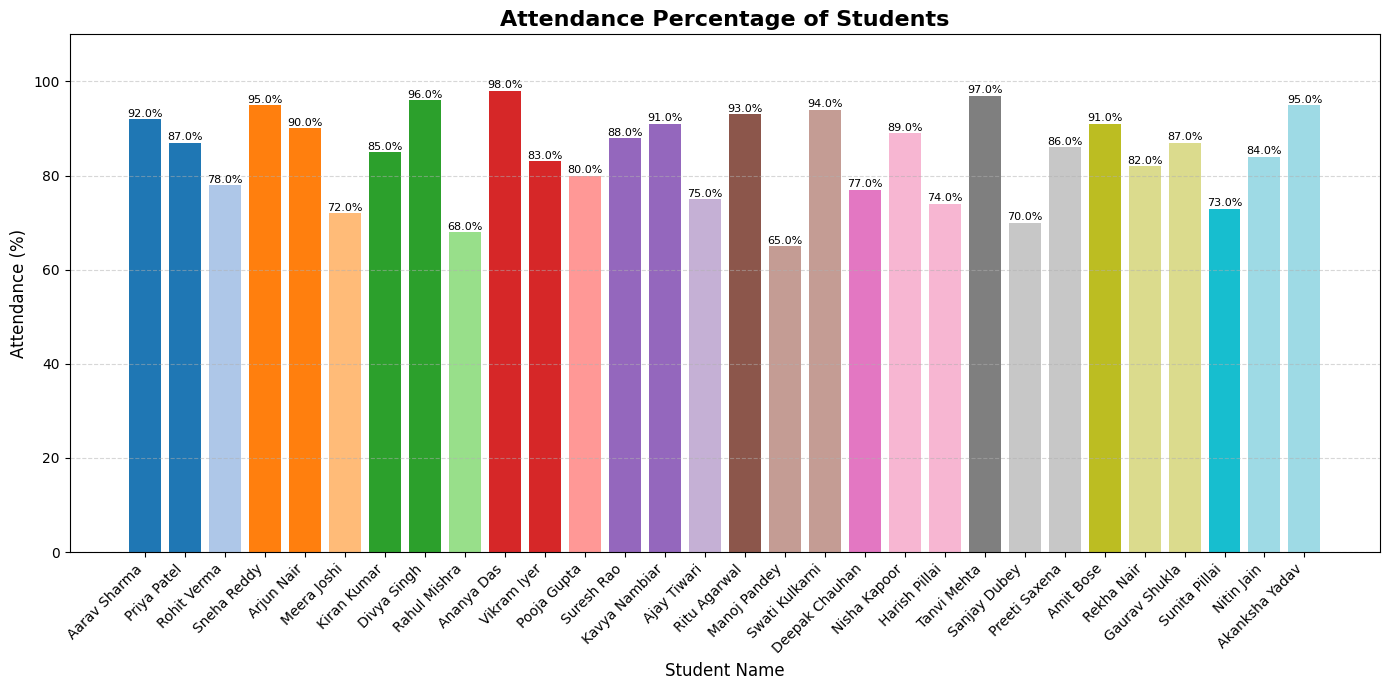

In [8]:
import numpy as np
colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

plt.figure(figsize=(14, 7))
bars = plt.bar(df['name'], df['attendance_percentage'], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{height:.1f}%',
             ha='center',
             fontsize=8)

plt.title('Attendance Percentage of Students', fontsize=16, fontweight='bold')
plt.xlabel('Student Name', fontsize=12)
plt.ylabel('Attendance (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

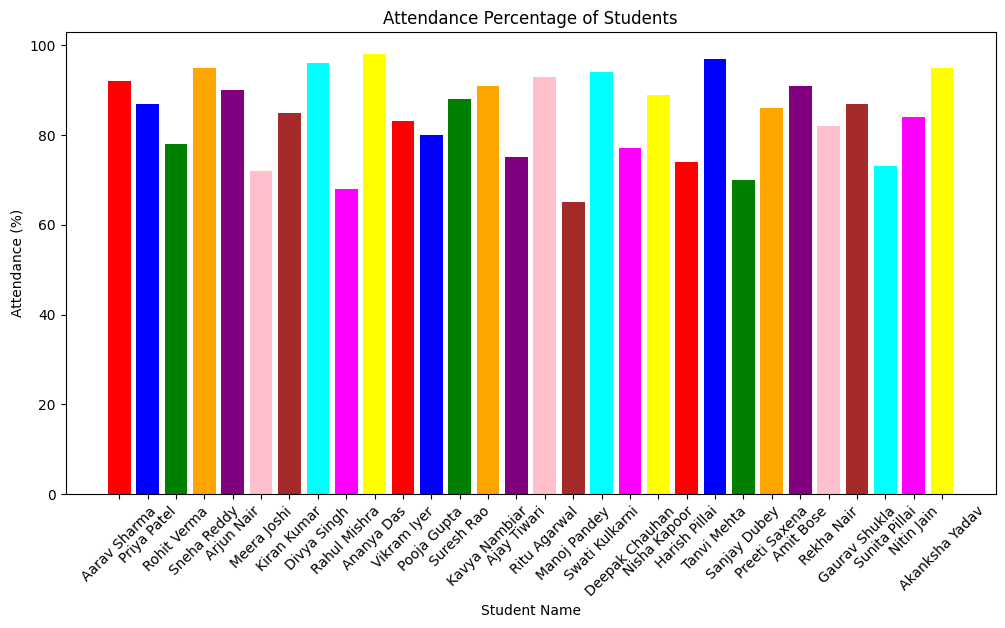

In [9]:
plt.figure(figsize=(12,6))
plt.bar(df['name'], df['attendance_percentage'],
        color=['red','blue','green','orange','purple','pink','brown','cyan','magenta','yellow'])

plt.title('Attendance Percentage of Students')
plt.xlabel('Student Name')
plt.ylabel('Attendance (%)')
plt.xticks(rotation=45)
plt.show()

In [10]:
import requests

API_KEY = "33499632c1a18060c1259394749d19ef"

city = "Chennai"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()
    print("City:", data["name"])
    print("Temperature:", round(data["main"]["temp"] - 273.15, 2), "°C")
    print("Humidity:", data["main"]["humidity"], "%")
    print("Weather:", data["weather"][0]["description"])
    print("Wind Speed:", data["wind"]["speed"], "m/s")
else:
    print(f"Error fetching data: {response.status_code} - {response.text}")

City: Chennai
Temperature: 34.29 °C
Humidity: 63 %
Weather: overcast clouds
Wind Speed: 4.02 m/s


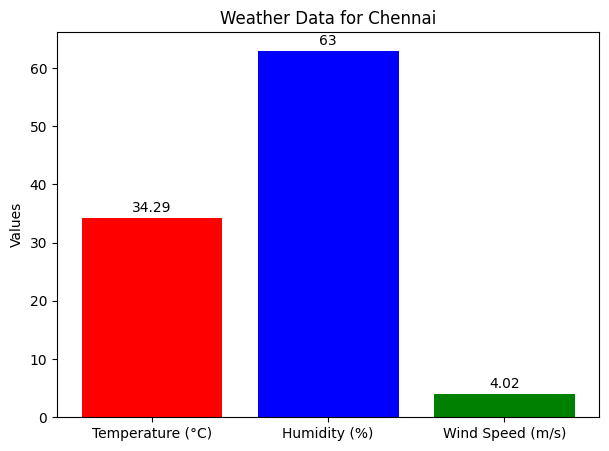

In [11]:
import requests
import matplotlib.pyplot as plt

API_KEY = "33499632c1a18060c1259394749d19ef"

city = "Chennai"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()

    temp = round(data["main"]["temp"] - 273.15, 2)
    humidity = data["main"]["humidity"]
    wind = data["wind"]["speed"]

    labels = ["Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)"]
    values = [temp, humidity, wind]

    plt.figure(figsize=(7,5))
    plt.bar(labels, values, color=['red', 'blue', 'green'])

    plt.title(f"Weather Data for {city}")
    plt.ylabel("Values")

    for i, v in enumerate(values):
        plt.text(i, v + 1, str(v), ha='center')

    plt.show()

else:
    print(f"Error fetching data: {response.status_code}")

In [12]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("StudentAnalysis").getOrCreate()

df = spark.read.csv("/content/student_performance.csv",
                    header=True,
                    inferSchema=True)

df.show()

+----------+--------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+----------+--------------+
|student_id|          name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|      city|admission_year|
+----------+--------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+----------+--------------+
|      1001|  Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|    Mumbai|          2023|
|      1002|   Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87| Ahmedabad|          2023|
|      1003|   Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|     De

In [13]:
df.select("name", "attendance_percentage").show()

+--------------+---------------------+
|          name|attendance_percentage|
+--------------+---------------------+
|  Aarav Sharma|                   92|
|   Priya Patel|                   87|
|   Rohit Verma|                   78|
|   Sneha Reddy|                   95|
|    Arjun Nair|                   90|
|   Meera Joshi|                   72|
|   Kiran Kumar|                   85|
|   Divya Singh|                   96|
|  Rahul Mishra|                   68|
|    Ananya Das|                   98|
|   Vikram Iyer|                   83|
|   Pooja Gupta|                   80|
|    Suresh Rao|                   88|
| Kavya Nambiar|                   91|
|   Ajay Tiwari|                   75|
|  Ritu Agarwal|                   93|
|  Manoj Pandey|                   65|
|Swati Kulkarni|                   94|
|Deepak Chauhan|                   77|
|  Nisha Kapoor|                   89|
+--------------+---------------------+
only showing top 20 rows


In [14]:
df.filter(df.attendance_percentage < 75).show()

+----------+-------------+---+------+-----------+--------+----------+-------------+-------------+-----------------+---------------------+------------------+--------------+
|student_id|         name|age|gender| department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|              city|admission_year|
+----------+-------------+---+------+-----------+--------+----------+-------------+-------------+-----------------+---------------------+------------------+--------------+
|      1006|  Meera Joshi| 20|Female|Electronics|       2|        58|           66|           70|               52|                   72|              Pune|          2023|
|      1009| Rahul Mishra| 20|  Male| Mechanical|       2|        62|           71|           58|               45|                   68|          Varanasi|          2023|
|      1017| Manoj Pandey| 21|  Male|      Civil|       2|        56|           61|           55|               38|                   65|   

In [16]:
from pyspark.sql.functions import when

df = df.withColumn(
    "recommended_domain",
    when(df.programming_score >= 85, "Software Development")
    .when(df.math_score >= 85, "Data Science")
    .when(df.english_score >= 85, "Technical Writing")
    .otherwise("General Engineering")
)

df.select("name", "recommended_domain").show()

+--------------+--------------------+
|          name|  recommended_domain|
+--------------+--------------------+
|  Aarav Sharma|Software Development|
|   Priya Patel|   Technical Writing|
|   Rohit Verma| General Engineering|
|   Sneha Reddy| General Engineering|
|    Arjun Nair|Software Development|
|   Meera Joshi| General Engineering|
|   Kiran Kumar| General Engineering|
|   Divya Singh|Software Development|
|  Rahul Mishra| General Engineering|
|    Ananya Das|Software Development|
|   Vikram Iyer| General Engineering|
|   Pooja Gupta| General Engineering|
|    Suresh Rao|Software Development|
| Kavya Nambiar| General Engineering|
|   Ajay Tiwari| General Engineering|
|  Ritu Agarwal|        Data Science|
|  Manoj Pandey| General Engineering|
|Swati Kulkarni|Software Development|
|Deepak Chauhan| General Engineering|
|  Nisha Kapoor| General Engineering|
+--------------+--------------------+
only showing top 20 rows
